In [1]:
import pandas as pd

In [3]:
df = pd.read_csv('superstoresales.csv', encoding = 'latin-1')

In [10]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
df.index = df.index + 1
df.head()

(9800, 18)
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
1,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
2,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
3,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
4,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
5,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [13]:
# Only 11 nulls values and they are in one column
# We need to modify three columns: Order Date and Ship Date needs modify object to time
### Postal code needs modify to text

In [17]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst = True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst = True)
df['Postal Code'] = df['Postal Code'].astype(str).str.replace('.0', '', regex = False)
df['Postal Code'] = df['Postal Code'].replace('nan', 'Wtihout Code')
print(df.dtypes)
print(df['Postal Code'].isnull().sum())

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code              object
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object
0


In [18]:
# Columns Calculated

In [20]:
df['Days to Ship'] = (df['Ship Date'] - df['Order Date']).dt.days
df['Order Month'] = df['Order Date'].dt.month
df['Order Year'] = df['Order Date'].dt.year
df['Quarter'] = df['Order Date'].dt.quarter
df[['Order Date', 'Ship Date', 'Days to Ship', 'Order Month', 'Order Year', 'Quarter']]

,Order Date,Ship Date,Days to Ship,Order Month,Order Year,Quarter
1,2017-11-08,2017-11-11,3,11,2017,4
2,2017-11-08,2017-11-11,3,11,2017,4
3,2017-06-12,2017-06-16,4,6,2017,2
4,2016-10-11,2016-10-18,7,10,2016,4
5,2016-10-11,2016-10-18,7,10,2016,4
...,...,...,...,...,...,...
9796,2017-05-21,2017-05-28,7,5,2017,2
9797,2016-01-12,2016-01-17,5,1,2016,1
9798,2016-01-12,2016-01-17,5,1,2016,1
9799,2016-01-12,2016-01-17,5,1,2016,1


In [21]:
df.to_csv('superstore_clean.csv', index = False)

In [23]:
import os
print(os.path.exists('superstore_clean.csv'))
print(df.shape)

False
(9800, 22)


In [24]:
import os
print(os.getcwd())

C:\Users\PC\Untitled Folder


In [26]:
# Exportar a CSV especificando la carpeta del proyecto
df.to_csv(r'C:\Users\PC\OneDrive\Documentos\Proyecto Ventas\Data\Clean\superstoresalesclean.csv', 
          index=False)
# r'' antes de la ruta evita que Python malinterprete los backslash de Windows

# Verificar
import os
print(os.path.exists(r'C:\Users\PC\OneDrive\Documentos\Proyecto Ventas\Data\Clean\superstoresalesclean.csv'))

True


In [70]:
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df = pd.read_csv('superstoresalesclean.csv')
conn = sqlite3.connect(r'C:\Users\PC\OneDrive\Documentos\Proyecto Ventas\ventas.db')

In [32]:
df.to_sql('fact_ventas', conn, if_exists = 'replace', index = False)

9800

In [35]:
query = pd.read_sql('SELECT COUNT(*) as total_registers FROM fact_ventas', conn)
print(query)

   total_registers
0             9800


In [36]:
dim_clients = df[['Customer ID', 'Customer Name', 'Segment']].drop_duplicates()

In [37]:
dim_clients.to_sql('dim_clients', conn, if_exists = 'replace', index = False)

793

In [40]:
dim_products = df[['Product ID', 'Product Name', 'Category', 'Sub-Category']].drop_duplicates()
dim_products.to_sql('dim_products', conn, if_exists = 'replace', index = False)

1893

In [45]:
dim_ubication = df[['City', 'State', 'Region', 'Postal Code']].drop_duplicates()
dim_ubication.to_sql('dim_ubication', conn, if_exists = 'replace', index = False)


628

In [46]:
dim_time = df[['Order Date', 'Order Month', 'Order Year', 'Quarter']]. drop_duplicates()
dim_time.to_sql('dim_time', conn, if_exists = 'replace', index = False)

1230

In [49]:
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type = 'table'", conn)

In [50]:
print(tables)

            name
0    fact_ventas
1    dim_clients
2   dim_products
3  dim_ubication
4       dim_time


In [71]:
query1 = pd.read_sql('''
    SELECT
        Category,
        ROUND(SUM(Sales), 2) AS revenue_total,
        COUNT(*) AS num_orders,
        ROUND(AVG(Sales), 2) AS mid_ticket
        FROM fact_ventas
        GROUP BY Category
        ORDER BY revenue_total DESC
''', conn)
print(query1)

          Category  revenue_total  num_orders  mid_ticket
0       Technology      827455.87        1813      456.40
1        Furniture      728658.58        2078      350.65
2  Office Supplies      705422.33        5909      119.38


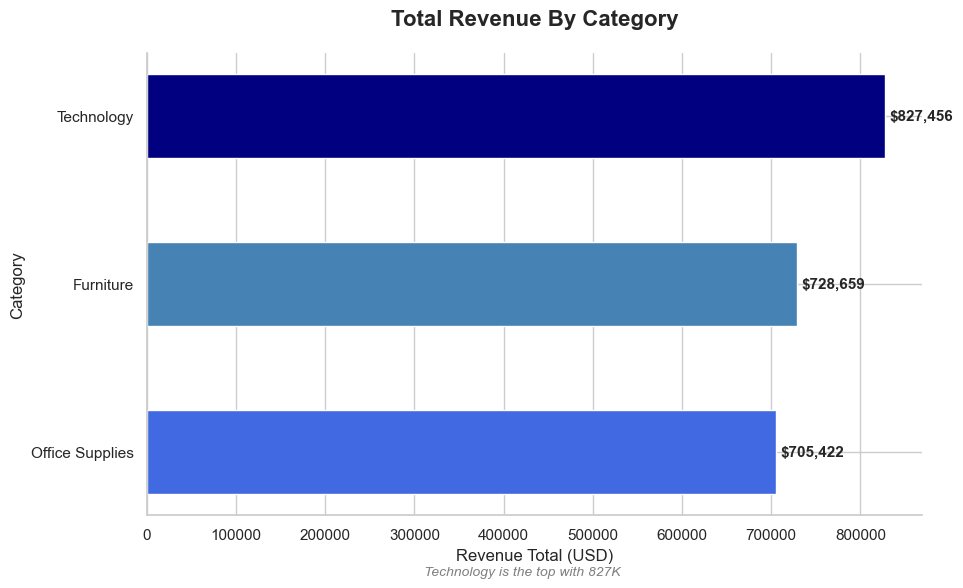

In [90]:
sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))
query1_sorted = query1.sort_values('revenue_total', ascending=True)
bars = ax.barh(
    query1_sorted['Category'],       
    query1_sorted['revenue_total'],  
    color = ['royalblue', 'steelblue', 'navy'],  
    edgecolor = 'white',               
    height = 0.5                       
)
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 5000,               
        bar.get_y() + bar.get_height() / 2,  
        f'${width:,.0f}',            
        va = 'center',                 
        fontsize = 11,
        fontweight = 'bold'
    )
ax.set_title('Total Revenue By Category', fontsize = 16, fontweight = 'bold', pad = 20)
ax.set_xlabel('Revenue Total (USD)', fontsize = 12)
ax.set_ylabel('Category', fontsize = 12)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.figtext(
    0.5, 0.01,
    'Technology is the top with 827K',
    ha = 'center', fontsize = 10, style = 'italic', color = 'gray'
)
plt.show()

In [59]:
query2 = pd.read_sql('''
     SELECT
         Region,
         ROUND(SUM(SALES), 2) AS revenue_total,
         COUNT(*) AS num_orders
         FROM fact_ventas
         GROUP BY Region
         ORDER BY revenue_total DESC
''', conn)
print(query2)

    Region  revenue_total  num_orders
0     West      710219.68        3140
1     East      669518.73        2785
2  Central      492646.91        2277
3    South      389151.46        1598


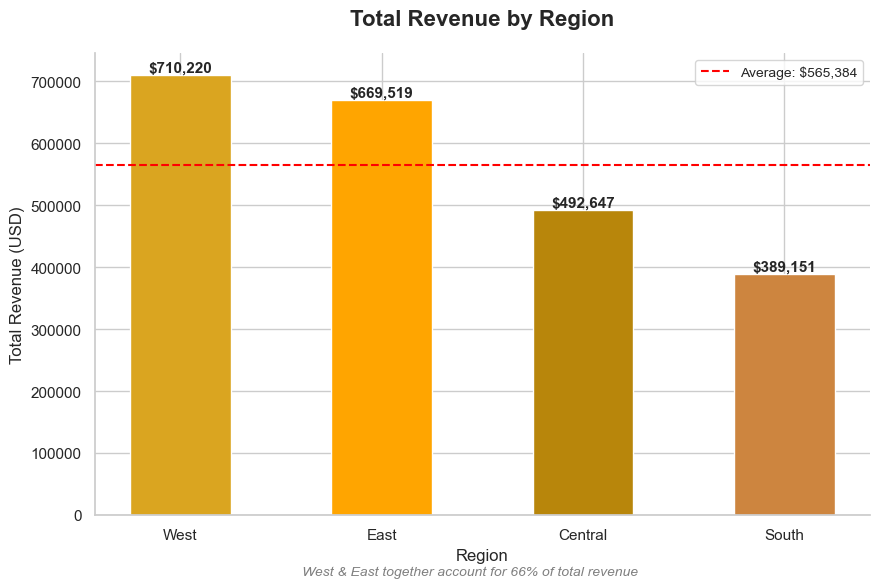

In [91]:
query2_sorted = query2.sort_values('revenue_total', ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['goldenrod', 'orange', 'darkgoldenrod', 'peru']
bars = ax.bar(
    query2_sorted['Region'],
    query2_sorted['revenue_total'],
    color= colors,
    edgecolor = 'white',
    width = 0.5
)
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5000,
        f'${height:,.0f}',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )
ax.set_title('Total Revenue by Region', fontsize=16, fontweight = 'bold', pad = 20)
ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Total Revenue (USD)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
promedio = query2['revenue_total'].mean()
ax.axhline(promedio, color='red', linestyle = '--', linewidth = 1.5, label = f'Average: ${promedio:,.0f}')
ax.legend(fontsize = 10)
plt.figtext(0.5, 0.01, 'West & East together account for 66% of total revenue',
            ha = 'center', fontsize=10, style='italic', color='gray')
plt.show()

In [64]:
query3 = pd.read_sql('''
    SELECT
    [Order Year],
    Quarter,
    ROUND(SUM(Sales), 2) AS revenue_total
    FROM fact_ventas
    GROUP BY [Order Year], Quarter                    
    ORDER BY [Order Year], Quarter
''', conn)
print(query3)

    Order Year  Quarter  revenue_total
0         2015        1       73931.40
1         2015        2       85874.09
2         2015        3      142522.61
3         2015        4      177528.11
4         2016        1       62357.69
5         2016        2       87713.37
6         2016        3      128560.21
7         2016        4      180804.74
8         2017        1       92686.37
9         2017        2      135061.16
10        2017        3      138056.37
11        2017        4      234388.65
12        2018        1      122260.88
13        2018        2      127558.62
14        2018        3      193815.84
15        2018        4      278416.67


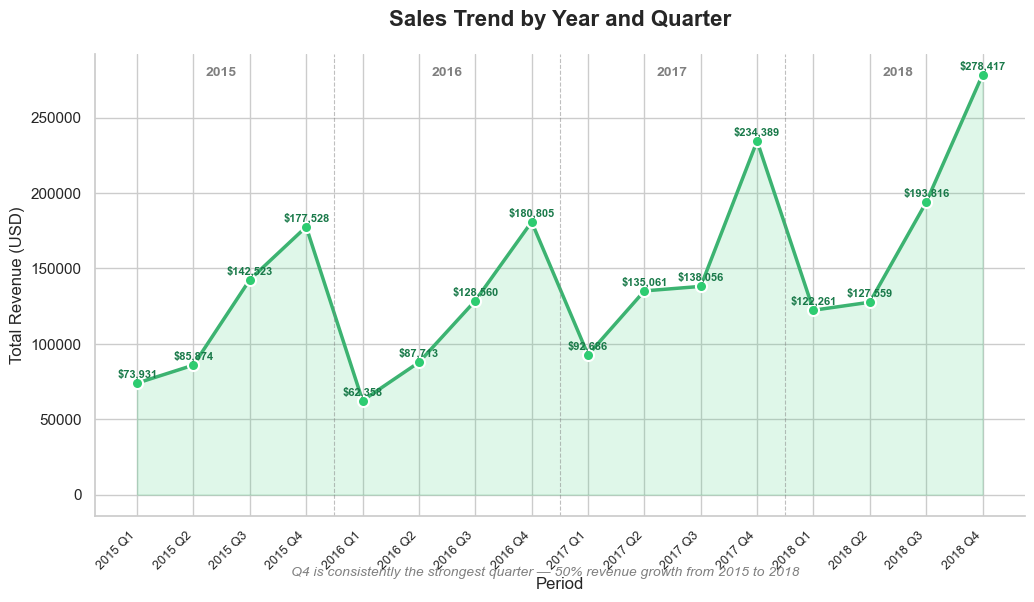

In [93]:
fig, ax = plt.subplots(figsize=(12, 6))
query3['period'] = query3['Order Year'].astype(str) + ' Q' + query3['Quarter'].astype(str)
ax.plot(
    query3['period'],
    query3['revenue_total'],
    color = 'mediumseagreen',
    linewidth = 2.5,
    marker = 'o',
    markersize = 8,
    markerfacecolor = '#2ecc71',
    markeredgecolor = 'white',
    markeredgewidth = 1.5
)
for i, row in query3.iterrows():
    ax.text(
        row['period'],
        row['revenue_total'] + 4000,
        f"${row['revenue_total']:,.0f}",
        ha = 'center',
        fontsize = 8,
        fontweight = 'bold',
        color='#1a7a4a'
    )
ax.fill_between(query3['period'], query3['revenue_total'], alpha = 0.15, color = '#2ecc71')
plt.xticks(rotation = 45, ha = 'right', fontsize = 9)
ax.set_title('Sales Trend by Year and Quarter', fontsize = 16, fontweight = 'bold', pad = 20)
ax.set_xlabel('Period', fontsize = 12)
ax.set_ylabel('Total Revenue (USD)', fontsize = 12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for x in [3.5, 7.5, 11.5]:
    ax.axvline(x, color = 'gray', linestyle ='--', linewidth = 0.8, alpha = 0.5)
for x, year in zip([1.5, 5.5, 9.5, 13.5], [2015, 2016, 2017, 2018]):
    ax.text(x, ax.get_ylim()[1] * 0.95, str(year),
            ha='center', fontsize = 10, color = 'gray', fontweight ='bold')
plt.figtext(0.5, 0.01, 'Q4 is consistently the strongest quarter — 50% revenue growth from 2015 to 2018',
            ha='center', fontsize=10, style='italic', color='gray')
plt.show()

In [68]:
query4 = pd.read_sql('''
    SELECT
        Region,
        Category,
        ROUND(SUM(Sales), 2) AS revenue_total,
        COUNT(*) AS num_orders
    FROM fact_ventas
    GROUP BY Region, Category
    ORDER BY Region, revenue_total DESC
''', conn)

# Renombrar columnas manualmente para corregir el orden
query4.columns = ['Region', 'Category', 'revenue_total', 'num_orders']
print(query4.to_string())

     Region         Category  revenue_total  num_orders
0   Central       Technology      168739.21         408
1   Central  Office Supplies      163590.24        1399
2   Central        Furniture      160317.46         470
3      East       Technology      263116.53         527
4      East        Furniture      206461.39         591
5      East  Office Supplies      199940.81        1667
6     South       Technology      148195.21         289
7     South  Office Supplies      124424.77         983
8     South        Furniture      116531.48         326
9      West       Technology      247404.93         589
10     West        Furniture      245348.25         691
11     West  Office Supplies      217466.51        1860


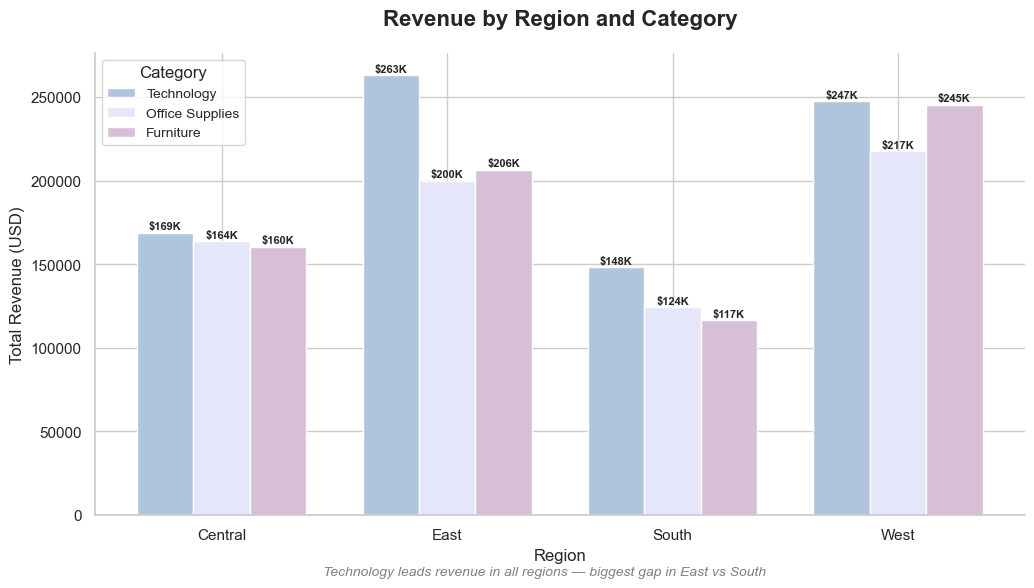

In [95]:
fig, ax = plt.subplots(figsize=(12, 6))
regions = query4['Region'].unique()
categories = query4['Category'].unique()
x = range(len(regions))
width = 0.25
colors = ['lightsteelblue', 'lavender', 'thistle']
for i, category in enumerate(categories):
    data = query4[query4['Category'] == category]
    bars = ax.bar(
        [pos + i * width for pos in x],
        data['revenue_total'],
        width = width,
        label = category,
        color = colors[i],
        edgecolor = 'white'
    )
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 2000,
            f'${height/1000:.0f}K',
            ha = 'center',
            fontsize = 8,
            fontweight = 'bold'
        )
ax.set_xticks([pos + width for pos in x])
ax.set_xticklabels(regions, fontsize = 11)
ax.set_title('Revenue by Region and Category', fontsize = 16, fontweight = 'bold', pad = 20)
ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Total Revenue (USD)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(title='Category', fontsize = 10)
plt.figtext(0.5, 0.01, 'Technology leads revenue in all regions — biggest gap in East vs South',
            ha='center', fontsize = 10, style = 'italic', color = 'gray')
plt.show()